# LSTM buy/sell signals: backtested

This is a reworked version of `Value_Notebook.03`, which is left unchanged
for reference. The network is the same as in .03: a 60-day input window,
two LSTM layers of 50 units, a dense output, Adam, mean squared error,
100 epochs, batch size 32. What changed:

- **Time runs forward.** The sheets are newest-first and .03 never sorted
  them, so its training windows ran backwards in time.
- **Scaling is fitted once, on the training period only.** .03 scaled the
  test data twice.
- **Test windows can reach back into 2020.** .03 built test windows from
  2021 data alone, which has fewer than 60 days, so it crashed.
- **No look-ahead.** .03's BUY/SELL rule compared the prediction for a day
  with that same day's actual price. Here a decision made at a day's close
  is traded at the next day's close.
- **Two forecasts per day.** The network predicts the next two closes, so
  the rule can ask whether the price will rise over the day the stock is
  actually held (the same rule as in `Prophet_Signal_Notebook.01`).
- **Results in money, against baselines.** Gains are measured in prices,
  not 0-1 scaled units, after 10 bp costs per trade, and compared with
  buy-and-hold and with "tomorrow = today".
- **All eight stocks, and repeated runs.** The sheet's eight stocks are all
  tested, and Sberbank is retrained with several random seeds, because a
  network's results can depend on its random starting point.

Two ways of feeding prices to the network are compared:

- **level** (as in .03): prices scaled to 0-1 using the training period's
  lowest and highest price. If test prices move outside that range, the
  network has never seen such values.
- **return**: daily log returns, scaled by their training-period standard
  deviation. This doesn't depend on the price level.

Nothing is tuned: the settings are .03's. This notebook takes about 12
minutes to run.

In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "setup.py").exists())
sys.path.insert(0, str(ROOT))

from src.data.prices import (EM_SPLITS, SPLITS, load_investing_sheets,
                             load_prices, period)
from src.evaluation.backtest import backtest, evaluate
from src.models import indicator_strategies as rules
from src.models.lstm_forecast import lstm_forecasts
from src.models.prophet_forecast import (forecast_accuracy, forecast_series,
                                         forecast_signal)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
pct = "{:.1%}"
ENCODINGS = ["level", "return"]

## Eight emerging-market stocks

Trained on 2020, tested on Q1 2021 (`EM_SPLITS`), as in .03. Prices are
in local currency and not adjusted for dividends. Forecasts start two
trading days before the test period so a position can be in place on its
first day. This cell takes about 6 minutes.

In [3]:
sheets = load_investing_sheets()
prices = {name.split(" - ")[0]: df["Close"] for name, df in sheets.items()}
TRAIN_END = EM_SPLITS["train"][1]


def decision_days(close, splits, first_period):
    first = close.index.get_loc(period(close, first_period, splits).index[0])
    return close.index[first - 2:]


forecasts = {
    (stock, enc): lstm_forecasts(close, TRAIN_END,
                                 decision_days(close, EM_SPLITS, "test"),
                                 target=enc, seed=0)
    for stock, close in prices.items() for enc in ENCODINGS
}

### Are the forecasts better than "tomorrow = today"?

Test period, one trading day ahead. `mape_naive` is the error of using
today's price as tomorrow's forecast; `up_day_share` is the hit rate of
always predicting "up".

In [4]:
accuracy = pd.DataFrame({
    (stock, f"lstm_{enc}"): forecast_accuracy(
        prices[stock], period(forecasts[stock, enc], "test", EM_SPLITS))
    for stock, enc in forecasts
}).T
accuracy.index.names = ["stock", "model"]
accuracy.unstack("model").style.format(pct)

In [5]:
accuracy.groupby("model").mean().style.format(pct)

,mape_model,mape_naive,direction_hit_rate,up_day_share
model,,,,
lstm_level,4.0%,1.7%,49.3%,49.3%
lstm_return,2.4%,1.7%,48.5%,49.3%


### Trading results

Test period, trades at the next day's close, 10 bp costs per trade.

In [6]:
def em_results(lag=1, cost_bps=10):
    tables = {}
    for stock, close in prices.items():
        states = {"buy_and_hold": rules.buy_and_hold(close)}
        for enc in ENCODINGS:
            states[f"lstm_{enc}"] = forecast_signal(
                close, forecasts[stock, enc], lag)
        bts = {name: backtest(close, s, lag=lag, cost_bps=cost_bps)
               for name, s in states.items()}
        tables[stock] = evaluate(bts, periods=("test",), splits=EM_SPLITS)
    return pd.concat(tables, names=["stock"]).droplevel("period")


results = em_results()
returns = results["total_return"].unstack("strategy")
returns = returns[["buy_and_hold", "lstm_level", "lstm_return"]]
returns.style.format(pct)

strategy,buy_and_hold,lstm_level,lstm_return
stock,,,
Russia,7.1%,7.0%,-2.3%
Turkey,-8.1%,0.1%,-5.2%
Egypt,-1.8%,-0.2%,5.1%
Brazil,0.2%,-4.2%,-1.2%
Argentina,10.7%,2.1%,14.7%
Colombia,-16.7%,-5.2%,-14.4%
South Africa,35.6%,11.3%,17.6%
South Korea,68.1%,23.5%,34.9%


Per stock: how often each strategy was in the market and how many
trades it made.

In [7]:
results[["total_return", "sharpe", "exposure", "trades"]].unstack(
    "strategy").style.format({
        ("total_return", s): pct for s in returns.columns} | {
        ("sharpe", s): "{:.2f}" for s in returns.columns} | {
        ("exposure", s): "{:.0%}" for s in returns.columns} | {
        ("trades", s): "{:.0f}" for s in returns.columns})

In [8]:
summary = results.groupby("strategy")[
    ["total_return", "sharpe", "max_drawdown", "exposure", "trades"]].mean()
summary["beat buy_and_hold"] = [
    (returns[s] > returns["buy_and_hold"]).sum() for s in summary.index]
summary.style.format({
    "total_return": pct, "sharpe": "{:.2f}", "max_drawdown": pct,
    "exposure": "{:.0%}", "trades": "{:.1f}",
    "beat buy_and_hold": "{} of 8"})

,total_return,sharpe,max_drawdown,exposure,trades,beat buy_and_hold
strategy,,,,,,
buy_and_hold,11.9%,0.72,-14.6%,100%,1.0,0 of 8
lstm_level,4.3%,0.79,-7.0%,38%,2.2,3 of 8
lstm_return,6.2%,0.26,-10.7%,57%,3.6,4 of 8


Average test-period return under different timing and cost assumptions.
"Same day, free" is closest to what .03 attempted.

In [9]:
settings = {
    "next day, 10bp": dict(lag=1, cost_bps=10),
    "next day, free": dict(lag=1, cost_bps=0),
    "same day, free": dict(lag=0, cost_bps=0),
}
pd.DataFrame({
    label: em_results(**kw)["total_return"].groupby("strategy").mean()
    for label, kw in settings.items()
}).style.format(pct)

,"next day, 10bp","next day, free","same day, free"
strategy,,,
buy_and_hold,11.9%,11.9%,11.9%
lstm_level,4.3%,4.7%,8.7%
lstm_return,6.2%,6.9%,2.0%


## How much does the random seed matter?

Sberbank, retrained with five different random seeds (seed 0 is the run
above). Nothing else changes between rows. This cell takes about 3
minutes.

In [10]:
close = prices["Russia"]
seed_rows = {}
for enc in ENCODINGS:
    for seed in range(5):
        fc = (forecasts["Russia", enc] if seed == 0 else
              lstm_forecasts(close, TRAIN_END,
                             decision_days(close, EM_SPLITS, "test"),
                             target=enc, seed=seed))
        bt = backtest(close, forecast_signal(close, fc, lag=1), lag=1,
                      cost_bps=10)
        acc = forecast_accuracy(close, period(fc, "test", EM_SPLITS))
        seed_rows[f"lstm_{enc}", seed] = {
            "mape_model": acc["mape_model"],
            "direction_hit_rate": acc["direction_hit_rate"],
            "total_return": period(bt["ret"], "test", EM_SPLITS)
            .add(1).prod() - 1,
        }
seeds = pd.DataFrame(seed_rows).T
seeds.index.names = ["model", "seed"]
bh = backtest(close, rules.buy_and_hold(close), cost_bps=10)
bh_return = period(bh["ret"], "test", EM_SPLITS).add(1).prod() - 1
print(f"Sberbank buy-and-hold, test period: {bh_return:.1%}")
seeds.style.format(pct)

Sberbank buy-and-hold, test period: 7.1%


In [11]:
seeds.groupby("model").agg(["min", "max"]).style.format(pct)

## AAPL: much more training data

The emerging-market sheets give the network only about 190 training
windows. AAPL's snapshot allows training on 2010-2017 (about 1,950
windows), with 2018-2019 and 2020 to Q1 2021 as two separate
out-of-sample periods (`SPLITS`). Only the return encoding is used: AAPL
traded far above its 2010-2017 range afterwards, which the level
encoding cannot represent. This cell takes about 3 minutes.

In [12]:
aapl = load_prices("AAPL")["Adj Close"]
aapl_fc = lstm_forecasts(aapl, SPLITS["train"][1],
                         decision_days(aapl, SPLITS, "validation"),
                         target="return", seed=0)

aapl_acc = pd.DataFrame({
    name: forecast_accuracy(aapl, period(aapl_fc, name))
    for name in ["validation", "test"]
}).T
aapl_acc.style.format(pct)

,mape_model,mape_naive,direction_hit_rate,up_day_share
validation,1.9%,1.2%,53.3%,54.9%
test,2.4%,2.0%,52.7%,52.4%


In [13]:
aapl_bts = {
    "buy_and_hold": backtest(aapl, rules.buy_and_hold(aapl), cost_bps=10),
    "lstm_return": backtest(aapl, forecast_signal(aapl, aapl_fc, lag=1),
                            cost_bps=10),
}
evaluate(aapl_bts, periods=("validation", "test")).style.format({
    "total_return": pct, "cagr": pct, "ann_vol": pct, "sharpe": "{:.2f}",
    "max_drawdown": pct, "exposure": "{:.0%}", "trades": "{:.0f}",
    "win_rate": "{:.0%}",
})

## Charts

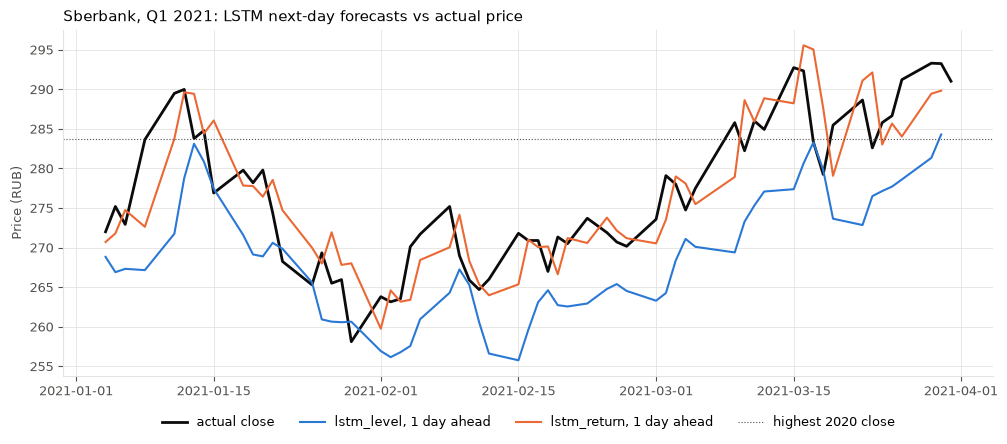

In [14]:
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834"]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9,
    "legend.frameon": False, "lines.linewidth": 1.5,
})

close = prices["Russia"]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(period(close, "test", EM_SPLITS), color=INK, linewidth=2,
        label="actual close")
for enc, color in zip(ENCODINGS, SERIES):
    path = forecast_series(close, forecasts["Russia", enc])
    ax.plot(period(path, "test", EM_SPLITS), color=color,
            label=f"lstm_{enc}, 1 day ahead")
ax.axhline(period(close, "train", EM_SPLITS).max(), color=MUTED,
           linewidth=0.8, linestyle=":", label="highest 2020 close")
ax.set_ylabel("Price (RUB)")
ax.set_title("Sberbank, Q1 2021: LSTM next-day forecasts vs actual price")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4)
plt.show()

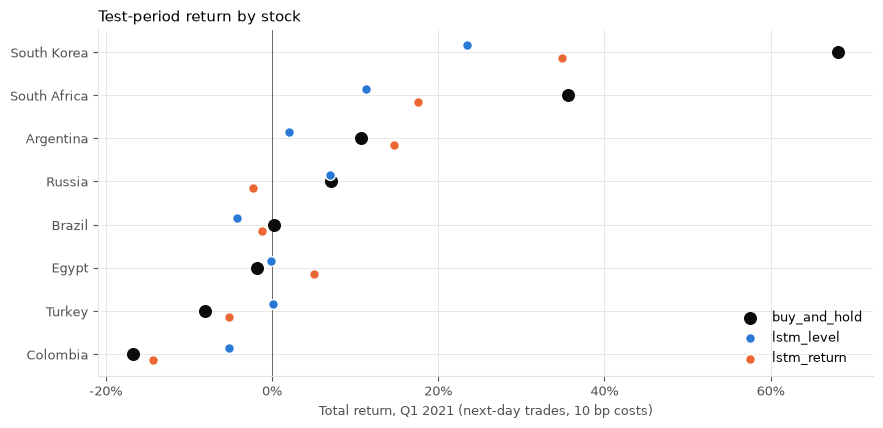

In [15]:
order = returns["buy_and_hold"].sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
y = range(len(order))
ax.scatter(returns.loc[order, "buy_and_hold"], y, s=70, color=INK,
           zorder=3, label="buy_and_hold")
# Small vertical offsets keep equal returns from hiding each other.
for enc, color, dy in zip(ENCODINGS, SERIES, [0.15, -0.15]):
    ax.scatter(returns.loc[order, f"lstm_{enc}"], [v + dy for v in y],
               s=50, color=color, edgecolor="white", linewidth=1,
               zorder=3, label=f"lstm_{enc}")
ax.axvline(0, color=MUTED, linewidth=0.6)
ax.set_yticks(list(y), order)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Total return, Q1 2021 (next-day trades, 10 bp costs)")
ax.set_title("Test-period return by stock")
ax.legend(loc="lower right")
plt.show()

## What the results support

- **Neither version forecasts tomorrow's price better than today's price
  does.** Average next-day error is 4.2% for the level encoding and 2.5%
  for the return encoding, against 1.7% for "tomorrow = today". The
  level encoding is worse than that on every stock; the return encoding
  is no better on any stock (Brazil is about a tie).
- **The return encoding mostly learns to repeat yesterday's price.** In
  the Sberbank chart its forecast is close to the actual price shifted
  one day later, which is why its error is close to the naive one.
- **The level encoding can't follow prices into new territory.** On five
  of the eight stocks the Q1 2021 price went above anything in the 2020
  training data. In the Sberbank chart the level forecast barely rises
  above the 2020 high while the price spends much of March above it.
- **Up/down calls are a coin flip:** 49% (level) and 48% (return)
  correct, the same as always guessing "up" (49%).
- **Both strategies earn less than buy-and-hold:** 4.3% (level) and 3.2%
  (return) on average, against 11.9%, beating it on 3 and 2 of 8 stocks.
  The level encoding's higher average Sharpe ratio is not a sign of
  skill: it never bought Turkey (so Turkey, buy-and-hold's worst stock,
  drops out of its average), held Sberbank all quarter, and was in the
  market under 10% of the time on Argentina and Colombia.
- **The random seed alone changes the answer.** Retraining the
  return-encoding model on Sberbank with five seeds gives up/down hit
  rates from 39% to 63% and returns from -7.7% to +10.9%. A single
  training run that looks good may just be a lucky starting point.
- **Eight years of training data doesn't rescue it.** On AAPL, the
  next-day error is 2.0% vs 1.2% naive (2018-2019) and 2.4% vs 2.0%
  (test). In the test period its up/down hit rate (54.7%) is slightly
  above always-up (52.4%), yet the strategy lost 3.7% while buy-and-hold
  gained 65%: being right a little more often doesn't help when the
  wrong calls come on the big moves.

## Caveats

- The emerging-market test period is about 60 trading days, and each
  stock (other than Sberbank) was trained once, so single-stock results
  are noisy.
- The network settings are .03's and were not tuned. A different design
  might do better, but testing that fairly needs a validation period,
  which the emerging-market data is too short to provide.
- Emerging-market prices are in local currency and not adjusted for
  dividends; 10 bp is a low cost estimate for some of those markets.